In [ ]:
## Descriptive Statistics

In [5]:
## Importações das Bibliotecas:

import seaborn as sns
import matplotlib.pyplot as plt
import statistics as st
import pandas as pd
import numpy as np

In [6]:
# Load datasets

declarations = pd.read_csv("dataset1_declarations.csv")
holdings = pd.read_csv("dataset2_holdings.csv")

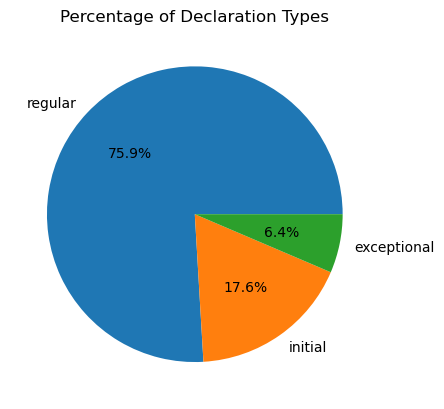

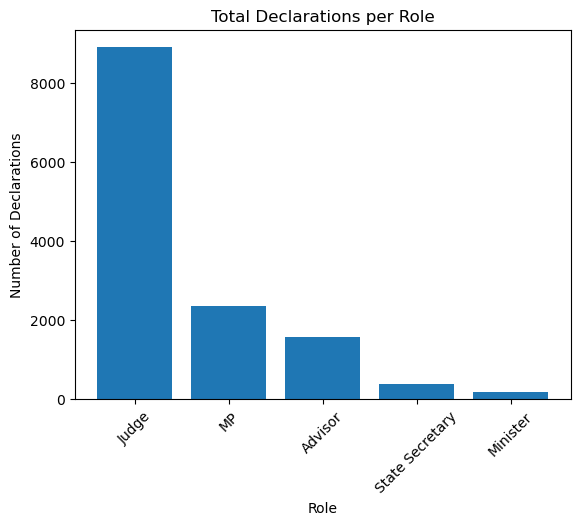

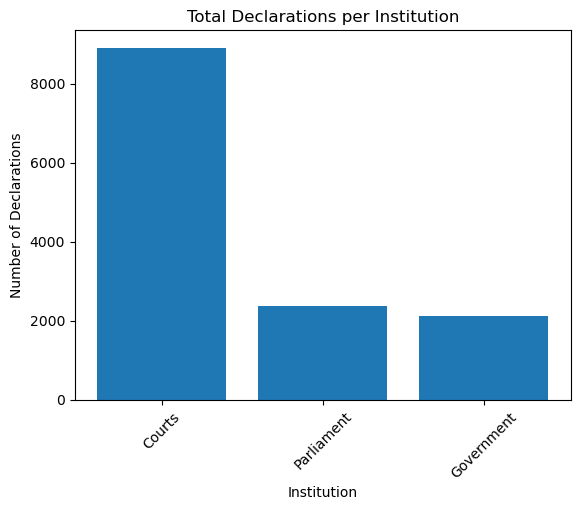

In [4]:
# US013


# PIE CHART
# Percentage of Declaration Types

declaration_counts = declarations["declaration_type"].value_counts()

plt.figure()

plt.pie(
    declaration_counts,
    labels=declaration_counts.index,
    autopct="%1.1f%%"
)

plt.title("Percentage of Declaration Types")

plt.show()


# BAR CHART
# Total Declarations per Role

role_counts = declarations["role"].value_counts()

plt.figure()

plt.bar(role_counts.index, role_counts.values)

plt.title("Total Declarations per Role")
plt.xlabel("Role")
plt.ylabel("Number of Declarations")

plt.xticks(rotation=45)

plt.show()


# BAR CHART
# Total Declarations per Institution

institution_counts = declarations["institution"].value_counts()

plt.figure()

plt.bar(institution_counts.index, institution_counts.values)

plt.title("Total Declarations per Institution")
plt.xlabel("Institution")
plt.ylabel("Number of Declarations")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# US014



# Convert date column
declarations["declaration_date"] = pd.to_datetime(declarations["declaration_date"])

# Keep ONLY most recent declaration per agent

latest_declarations = declarations.sort_values(
    "declaration_date"
).groupby("agent_id").tail(1)

# Create required variables

# Total Income
latest_declarations["total_income"] = (
        latest_declarations["gross_salary"]
        + latest_declarations["side_income_consulting"]
        + latest_declarations["side_income_board_memberships"]
)

# Total Assets
latest_declarations["total_assets"] = (
        latest_declarations["assets_in_real_estate"]
        + latest_declarations["assets_in_vehicles"]
        + latest_declarations["assets_in_stocks"]
)


# Central & Non-Central Measures

def descriptive_stats(series, name):
    print(f"\n===== {name} =====")

    print("\n--- Central Tendency ---")
    print("Mean:", series.mean())
    print("Median:", series.median())
    print("Mode:", series.mode().values)

    print("\n--- Non-Central Measures (Position) ---")
    print("Q1:", series.quantile(0.25))
    print("Q3:", series.quantile(0.75))
    print("Percentile 10:", series.quantile(0.10))
    print("Percentile 90:", series.quantile(0.90))

    print("\n--- Variability Measures ---")
    print("Range:", series.max() - series.min())
    print("Variance:", series.var())
    print("Standard Deviation:", series.std())
    print("Interquartile Range (IQR):",
          series.quantile(0.75) - series.quantile(0.25))


descriptive_stats(latest_declarations["total_income"], "TOTAL INCOME")
descriptive_stats(latest_declarations["total_assets"], "TOTAL ASSETS")


# Outlier Detection (IQR Method)

def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = series[(series < lower) | (series > upper)]

    print("\nOutliers detected:", len(outliers))
    return outliers


print("\n=== OUTLIERS - TOTAL INCOME ===")
income_outliers = detect_outliers(latest_declarations["total_income"])

print("\n=== OUTLIERS - TOTAL ASSETS ===")
assets_outliers = detect_outliers(latest_declarations["total_assets"])

# Visual Representation

# Histogram - Total Income
plt.figure()
plt.hist(latest_declarations["total_income"], bins=20)
plt.title("Distribution of Total Income")
plt.xlabel("Total Income (€)")
plt.ylabel("Frequency")
plt.show()

# Histogram - Total Assets
plt.figure()
plt.hist(latest_declarations["total_assets"], bins=20)
plt.title("Distribution of Total Assets")
plt.xlabel("Total Assets (€)")
plt.ylabel("Frequency")
plt.show()

# Boxplot comparison
plt.figure()
plt.boxplot(
    [
        latest_declarations["total_income"],
        latest_declarations["total_assets"]
    ],
    tick_labels=["Total Income", "Total Assets"]
)
plt.title("Boxplot Comparison: Income vs Assets")
plt.ylabel("Value (€)")
plt.show()

In [ ]:
# US015




# CONVERT DATE

declarations["declaration_date"] = pd.to_datetime(declarations["declaration_date"])



# LIST AGENTS

agents = declarations["agent_id"].unique()

print("List of Political Agents:")
for agent in agents:
    print(agent)



# CHOOSE AN AGENT

selected_agent = input("\nSelect the agent ID: ")



# FILTER DATA

agent_data = declarations[declarations["agent_id"] == (selected_agent)]

# ordenar por data
agent_data = agent_data.sort_values("declaration_date")



# CREATE VARIABLES

agent_data["total_extra_income"] = (
        agent_data["side_income_consulting"]
        + agent_data["side_income_board_memberships"]
)

agent_data["total_assets"] = (
        agent_data["assets_in_real_estate"]
        + agent_data["assets_in_vehicles"]
        + agent_data["assets_in_stocks"]
)



# GRAPHIC  1 – GROSS SALARY

plt.figure()

plt.plot(agent_data["declaration_date"], agent_data["gross_salary"])

plt.title("Evolution of Gross Salary")
plt.xlabel("Data")
plt.ylabel("Gross Salary (€)")

plt.xticks(rotation=45)
plt.show()



# GRAPHIC 2 – SUPPLEMENTARY INCOME

plt.figure()

plt.plot(agent_data["declaration_date"], agent_data["total_extra_income"])

plt.title("Trends in Supplementary Income")
plt.xlabel("Date")
plt.ylabel("Income (€)")

plt.xticks(rotation=45)
plt.show()



# GRAPHIC  3 – ASSETS

plt.figure()

plt.plot(agent_data["declaration_date"], agent_data["total_assets"])

plt.title("Asset Growth")
plt.xlabel("Date")
plt.ylabel("Value (€)")

plt.xticks(rotation=45)
plt.show()

In [ ]:
# US016



# Create Total Income

declarations["total_income"] = (
    declarations["gross_salary"] +
    declarations["side_income_consulting"] +
    declarations["side_income_board_memberships"]
)

# Boxplot

plt.figure(figsize=(12,6))

declarations.boxplot(
    column="total_income",
    by="role",
    grid=False
)

# Improve visualization

plt.title("Total Income Distribution by Role")
plt.suptitle("")  # remove automatic pandas title
plt.xlabel("Role")
plt.ylabel("Total Income (€)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Median income per role

median_income = declarations.groupby("role")["total_income"].median()
print("\nMedian income per role:")
print(median_income.sort_values(ascending=False))

# Dispersion (Standard Deviation)

dispersion = declarations.groupby("role")["total_income"].std()
print("\nIncome dispersion (Std Dev) per role:")
print(dispersion.sort_values(ascending=False))

Top 10 Companies with Highest Stock Values held by Political Agents:
    company_NIF  total_value
25    100000031    661372.12
48    100000069    626334.79
44    100000064    564134.33
32    100000040    552342.37
0     100000000    511550.02
57    100000080    484236.94
65    100000091    470563.11
8     100000010    467310.70
47    100000068    458345.84
40    100000058    440384.11


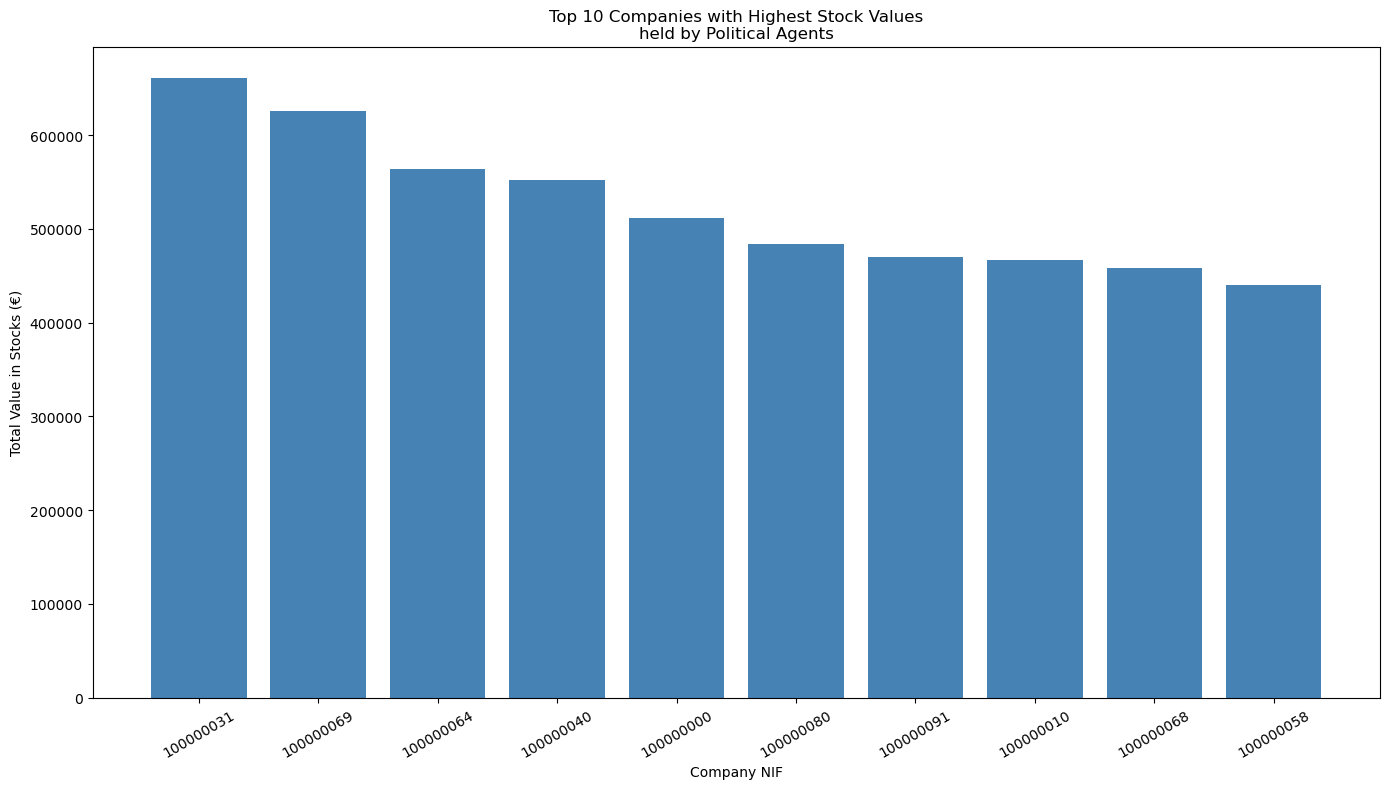

In [7]:
#US017



# Convert dates
holdings["declaration_date"] = pd.to_datetime(holdings["declaration_date"])


# PART 1 — GET MOST RECENT DECLARATION FOR EACH AGENT


most_recent = holdings.sort_values("declaration_date").groupby("agent_id").last().reset_index()


# PART 2 — CALCULATE TOTAL VALUE PER COMPANY


company_totals = most_recent.groupby("company_NIF")["total_value_in_stocks"].sum().reset_index()
company_totals.columns = ["company_NIF", "total_value"]

top10 = company_totals.sort_values("total_value", ascending=False).head(10)

print("Top 10 Companies with Highest Stock Values held by Political Agents:")
print(top10)

# PART 3 — BAR CHART


plt.figure(figsize=(14, 8))
plt.bar(
    top10["company_NIF"].astype(str),
    top10["total_value"],
    color="steelblue"
)

plt.xticks(rotation=30)
plt.title("Top 10 Companies with Highest Stock Values\nheld by Political Agents")
plt.xlabel("Company NIF")
plt.ylabel("Total Value in Stocks (€)")
plt.tight_layout()
plt.show()

In [ ]:
#US018



# Convert dates
holdings["declaration_date"] = pd.to_datetime(holdings["declaration_date"])


# PART 1 — CALCULATE INCREASE FOR EACH (AGENT, COMPANY)


grouped = holdings.groupby(["agent_id", "company_NIF"])

results = []

for (agent, company), group in grouped:
    group_sorted = group.sort_values("declaration_date")

    initial_value = group_sorted["total_value_in_stocks"].iloc[0]
    final_value = group_sorted["total_value_in_stocks"].iloc[-1]

    increase = final_value - initial_value

    results.append({
        "agent_id": agent,
        "company_NIF": company,
        "initial_value": initial_value,
        "final_value": final_value,
        "increase": increase,
        "history": group_sorted
    })

df_increase = pd.DataFrame(results)

# Top 10 increases
top10 = df_increase.sort_values("increase", ascending=False).head(10)

print(top10[["agent_id", "company_NIF", "increase"]])


# PART 2 — BAR CHART FOR TOP 10 INCREASES


plt.figure(figsize=(14, 8))
plt.bar(
    top10["agent_id"].astype(str) + " / " + top10["company_NIF"].astype(str),
    top10["increase"],
    color="steelblue"
)

plt.xticks(rotation=30)
plt.title("Top 10 Increases in Stock Value (Agent / Company)")
plt.ylabel("Increase in Value (€)")
plt.tight_layout()
plt.show()


# PART 3 — LINE CHARTS FOR EVOLUTION OVER TIME


for idx, row in top10.iterrows():
    history = row["history"]

    plt.figure(figsize=(10, 5))
    plt.plot(
        history["declaration_date"],
        history["total_value_in_stocks"],
        marker="o",
        linestyle="-",
        color="darkgreen"
    )

    plt.title(f"Evolution Over Time — Agent {row['agent_id']} / Company {row['company_NIF']}")
    plt.xlabel("Declaration Date")
    plt.ylabel("Value in Stocks (€)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
## US024


declarations.to_csv("US24_output.csv", index=False)

In [ ]:
## US025


holdings.to_csv("US25_output.csv", index=False)